# PedSilicoICH: Part 2. Scanners

This notebook also introduces concepts of the `Scanners` Class, and assumes familiarity with the [01_phantoms.ipynb](01_phantoms.ipynb) notebook and continues from it.

In [1]:
from insilicoICH.ground_truth_definition.phantoms import load_phantom
age = 6.5
phantom = load_phantom(age)

import numpy as np
volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(80, 50, 3)
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)

for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

phantom

inserting lesion 0/3:
{'volume': np.float64(0.05), 'intensity': np.float64(80.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 1/3:
{'volume': np.float64(0.275), 'intensity': np.float64(65.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 2/3:
{'volume': np.float64(0.5), 'intensity': np.float64(50.0), 'lesion_type': 'IPH', 'seed': 336}




        phantom class: NIHPD_Head
        age [yrs]: 6.5
        shape [voxels]: [189, 233, 197]
        size [mm]: [189. 233. 197.]
        
        Number of lesions: 3
        Lesion locations [voxel index (z, x, y)]: [(np.int64(94), np.int64(143), np.int64(46)), (np.int64(93), np.int64(97), np.int64(75)), (np.int64(93), np.int64(76), np.int64(88))]
        Mass effect: False
        

## Define the scanner that will image the patient phantom

In [2]:
from insilicoICH.image_acquisition import Scanner
Scanner?

Init signature:
Scanner(
    phantom: insilicoICH.ground_truth_definition.phantoms.Phantom,
    scanner_model: str = 'Scanner_Default',
    studyname: str = 'default',
    studyid: int = 0,
    seriesname: str = 'default',
    seriesid=0,
    framework: str = 'CATSIM',
    output_dir: str | pathlib.Path = None,
    materials: dict | None = None,
) -> None
Docstring:      A class to hold CT simulation data and run simulations
Init docstring:
:param phantom: Phantom class instance to be scanned, voxels in units of
    approximate CT Numbers [HU], typically in python
    coordinates (z, x, y)
    where z is perpendicular to the axial plane made by x and y.
    See <https://en.wikipedia.org/wiki/Hounsfield_scale>
    for some suggested values for common materials
:param scanner_model: str, study identifier to be used for virtual identifier and DICOM header
:param studyname: str, study identifier to be saved in DICOM header
:param studyid: int, study identifier to be saved in DICOM header
:

In [3]:
scanner = Scanner(phantom, scanner_model='GE_Lightspeed64')
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing default/phantoms/0/0_ncat_adipose


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: GE_Lightspeed64
        Simulation Platform: CATSIM
        

## Use `scanner.scout_view()` to determine scan range

Here we use the `phantom._lesion_coords` attribute to center the scan around the lesion location to update the center and number of `scans` to the desired scan length

Initializing Scanner object...
----------


*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing default/phantoms/0/0_ncat_adipose_197x233x189.raw...
* Writing default/phan

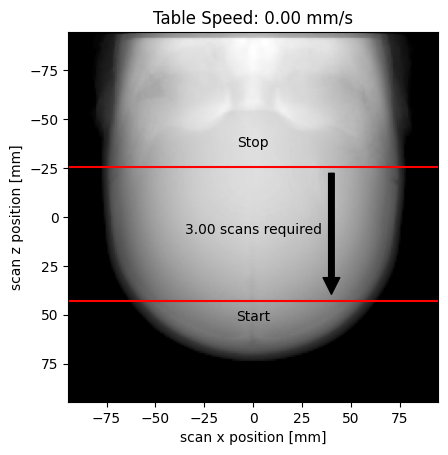

In [14]:
scanner = Scanner(phantom, scanner_model='GE_Lightspeed64')
lesion_level_mm = (phantom.get_CT_number_phantom().shape[0]/2 -
                   phantom._lesion_coords[0][0])*phantom.dz

scans = 3  # edit me

center = lesion_level_mm
width = scanner.scan_width*scans
startZ = center - width / 2
endZ = center + width / 2

scanner.scout_view(startZ, endZ)

Set `pitch=0` for axial scan

In [15]:
acquisition_technique = dict(
    mA=200,
    kVp=120,
    views=500,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)
scanner.run_scan(**acquisition_technique)

scan: 1/3
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    264 MB.


100%|██████████| 500/500 [06:43<00:00,  1.24it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
scan: 2/3
Airscan
Offset scan
Phantom scan


...

  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [06:41<00:00,  1.24it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: GE_Lightspeed64
        Simulation Platform: CATSIM
        

In [16]:
recon_technique = dict(
    kernel='soft',
    fov=250,
    sliceThickness=1
)
scanner.run_recon(**recon_technique)

fov size: 250
* Loading the projection data...


* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: GE_Lightspeed64
        Simulation Platform: CATSIM
        
Recon: (102, 512, 512) 25.0 cm fov
Projections: (500, 64, 900)

## View the result

In [17]:
%pip install -q matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [18]:
from utils import ctshow

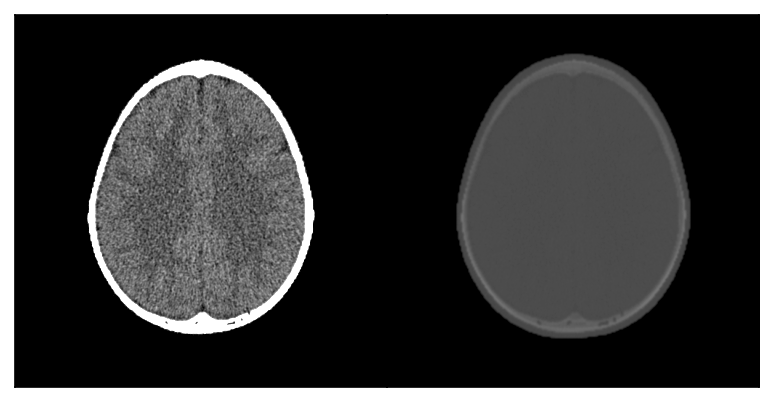

In [19]:
import matplotlib.pyplot as plt
f, axs = plt.subplots(1, 2, gridspec_kw=dict(wspace=0), dpi=150)
ctshow(scanner.recon[len(scanner.recon)//2], 'brain', fig=f, ax=axs[0])
ctshow(scanner.recon[len(scanner.recon)//2], 'temporal bones', fig=f, ax=axs[1])

In [ ]:
from utils import scrollview
scrollview(scanner.recon, 'brain')

interactive(children=(IntSlider(value=51, description='idx', max=101), Output()), _dom_classes=('widget-intera…

Now set `pitch=1` for a helical scan

In [21]:
acquisition_technique['pitch'] = 1
scanner.run_scan(**acquisition_technique)
scanner.run_recon(**recon_technique)

Airscan
Offset scan
Phantom scan


  0%|          | 0/1500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 1500/1500 [20:08<00:00,  1.24it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/103...
   recon slice 1/103...
   recon slice 2/103...
   recon slice 3/103...
   recon slice 4/103...
   recon slice 5/103...
   recon slice 6/103...
   recon slice 7/103...
   recon slice 8/103...
   recon slice 9/103...
   recon slice 10/103...
   recon slice 11/103...
   recon slice 12/103...
   recon slice 13/103...
   recon slice 14/103...
   recon slice 15/103...
   recon slice 16/103...
   recon slice 17/103...
   recon slice 18/103...
   recon slice 19/103...
   recon slice 20/103...
   recon slice 21/103...
   recon slice 22/103...
   recon slice 23/103...
   recon slice 24/103...
   recon slice 25/103...
   recon slice 26


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: GE_Lightspeed64
        Simulation Platform: CATSIM
        
Recon: (103, 512, 512) 25.0 cm fov
Projections: (1500, 64, 900)

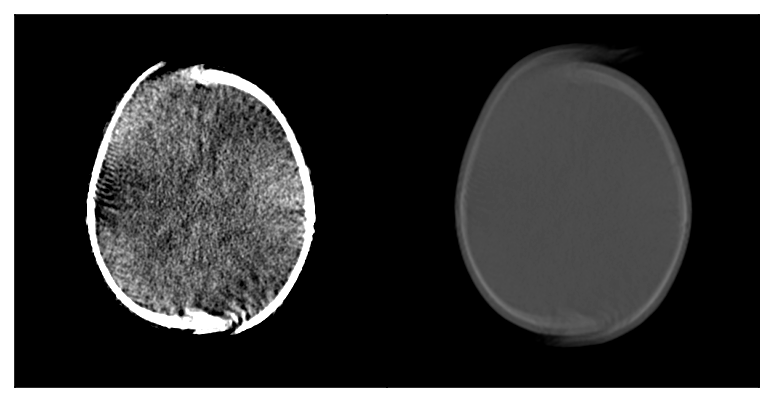

In [22]:
import matplotlib.pyplot as plt
f, axs = plt.subplots(1, 2, gridspec_kw=dict(wspace=0), dpi=150)
ctshow(scanner.recon[len(scanner.recon)//2], 'brain', fig=f, ax=axs[0])
ctshow(scanner.recon[len(scanner.recon)//2], 'temporal bones', fig=f, ax=axs[1])

In [23]:
scrollview(scanner.recon, 'brain')

interactive(children=(IntSlider(value=51, description='idx', max=102), Output()), _dom_classes=('widget-intera…

## Going Deeper

Below are more advance topics on how to get the lesion mask in the reconstructed image space and exploring more acquisition and reconstruction parameters

In [11]:
scanner.get_lesion_mask?

Signature:
scanner.get_lesion_mask(
    startZ: int | None = None,
    endZ: int | None = None,
    fov: float | None = None,
    slice_thickness=1,
    **kwargs,
) -> numpy.ndarray[bool]
Docstring:
takes lesion in object space and returns a mask in CT image space
for the given imaging system
File:      ~/Dev/PedSilicoICH/src/insilicoICH/image_acquisition.py
Type:      method

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ICRU_lung_adult_healthy', 'water']
* mu values (/cm): [0.05, 0.21]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.0, 0.19]
* Thresholds (HU): [-1000.0, -100.0]
*********************************************
* Calculating volume fraction maps for 2 materials and 189 slices...
* Writing volume fraction files for 2 materials and 189 slices, plus the HU data...
* Writing default/lesion_mask/lesion only/phantoms/0/0_ICRU_lung_adult_healthy_197x233x189.raw...
* 

  0%|          | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 100/100 [00:29<00:00,  3.38it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


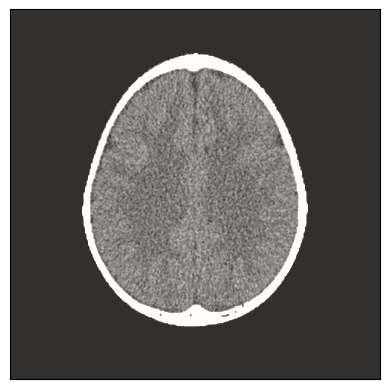

In [12]:
mask = scanner.get_lesion_mask(**acquisition_technique, **recon_technique)
ctshow(scanner.recon[len(scanner.recon)//2], 'brain')
plt.imshow(mask[len(scanner.recon)//2], cmap='Reds', alpha=0.2)

In [13]:
scanner_models = ['GE_LightGE_Lightspeed64', 'Siemens_DefinitionFlash']
scanner_recons = []
for scanner_model in scanner_models:
    scanner = Scanner(phantom, scanner_model='GE_Lightspeed64')
    scanner.run_scan(**acquisition_technique)
    scanner.run_recon(**recon_technique)
    scanner_recons.append(scanner.recon)

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing default/phantoms/0/0_ncat_adipose

  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


 25%|██▍       | 123/500 [01:40<05:06,  1.23it/s]


KeyboardInterrupt: 

In [ ]:
mAs = [20, 80, 320]
mA_recons = []
for mA in mAs:
    scanner.run_scan(mA=mA, startZ=startZ, endZ=endZ, views=500)
    scanner.run_recon(sliceThickness=1, kernel='soft')
    mA_recons.append(scanner.recon)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


 12%|█▏        | 60/500 [00:51<05:51,  1.25it/s]

100%|██████████| 500/500 [06:56<00:00,  1.20it/s]


...

Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [06:53<00:00,  1.21it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


In [ ]:
lesion_mask = scanner.get_lesion_mask(startZ=startZ, endZ=endZ)
lesion_mask.shape

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ICRU_lung_adult_healthy', 'water']
* mu values (/cm): [0.05, 0.21]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.0, 0.19]
* Thresholds (HU): [-1000.0, -100.0]
*********************************************
* Calculating volume fraction maps for 2 materials and 189 slices...
* Writing volume fraction files for 2 materials and 189 slices, plus the HU data...
* Writing default/lesion_mask/lesion only/phantoms/0/0_ICRU_lung_adult_healthy_197x233x189.raw...
* 

  0%|          | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 100/100 [00:31<00:00,  3.22it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


(34, 512, 512)

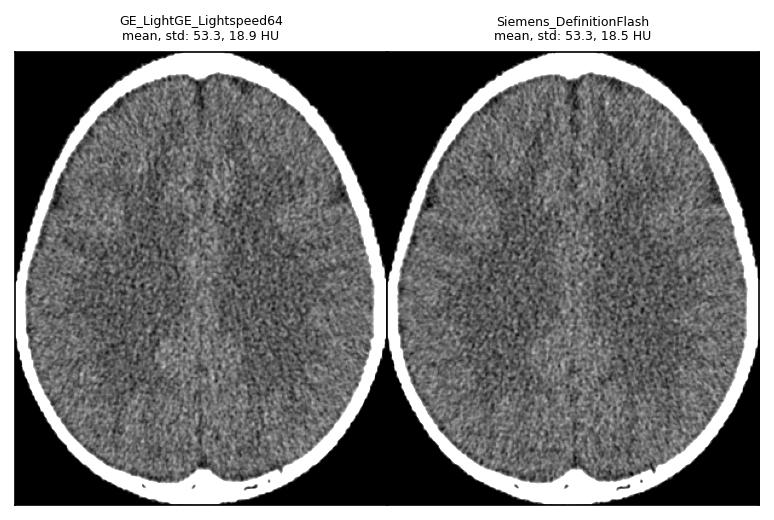

In [ ]:
import sys
sys.path.append('..')
from utils import ctshow, center_crop
import matplotlib.pyplot as plt

f, axs = plt.subplots(1, len(scanner_recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, scanner_model in zip(axs.flatten(), scanner_recons, scanner_models):
    ctshow(center_crop(recon[len(scanner.recon)//2]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{scanner_model}\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)

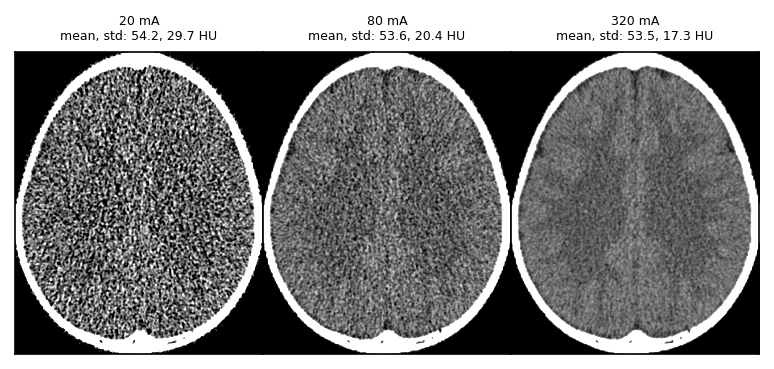

In [ ]:
f, axs = plt.subplots(1, len(mA_recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, mA in zip(axs.flatten(), mA_recons, mAs):
    ctshow(center_crop(recon[len(scanner.recon)//2]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{mA} mA\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)

In [ ]:
kVps = [80, 100, 120, 140]
kVp_recons = []
for kVp in kVps:
    mA = 200 * (120 / kVp)**2 # accounts for the fact that tube output scales by kVp^2
    print(f'{kVp} kVp, {mA} mA')
    scanner.run_scan(kVp=kVp, mA=mA, startZ=startZ, endZ=endZ, views=500)
    scanner.run_recon(sliceThickness=1, kernel='soft')
    kVp_recons.append(scanner.recon)

80 kVp, 450.0 mA
scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [06:52<00:00,  1.21it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
100 kVp, 288.0 mA
scan: 1/1
Airscan
Offset scan
Phantom scan


...

Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
140 kVp, 146.93877551020407 mA
scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [06:54<00:00,  1.21it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


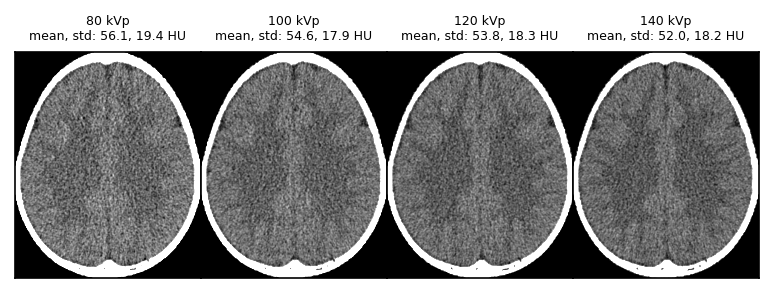

In [ ]:
f, axs = plt.subplots(1, len(kVp_recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, kVp in zip(axs.flatten(), kVp_recons, kVps):
    ctshow(center_crop(recon[len(scanner.recon)//2]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{kVp} kVp\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)
    

In [ ]:
scanner.run_scan(kVp=120, mA=200, startZ=startZ, endZ=endZ, views=500)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


 14%|█▍        | 69/500 [00:59<05:34,  1.29it/s]

100%|██████████| 500/500 [06:49<00:00,  1.22it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: GE_Lightspeed64
        Simulation Platform: CATSIM
        
Recon: (34, 512, 512) 25.0 cm fov
Projections: (500, 64, 900)

In [ ]:
kernels = ['bone', 'standard', 'soft']

recons = []
for kernel in kernels:
    scanner.run_recon(sliceThickness=1, kernel=kernel)
    recons.append(scanner.recon)

fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...


* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


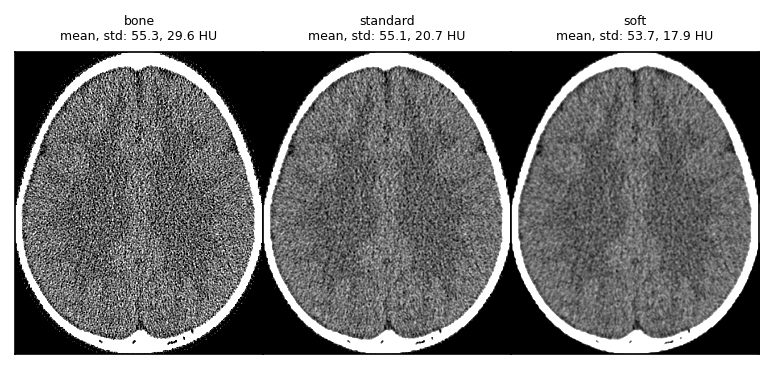

In [ ]:
f, axs = plt.subplots(1, len(recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, kernel in zip(axs.flatten(), recons, kernels):
    ctshow(center_crop(recon[len(scanner.recon)//2]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{kernel}\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)